# *Comparative analysis of the telecom plans profitability*

### Goal
Prepare a report for the telecom operator Megaline to analyze clients' behavior, determine which of the two prepaid plans is more profitable and test two statistical hypotheses.

### Hypotheses
1. The average profit from users of Ultimate and Surf calling plans differs.
2. The average profit from users in NY-NJ area is different from that of the users from other regions.

### Description of the data

Megaline rounds seconds up to minutes, and megabytes to gigabytes. For **calls**, each individual call is rounded up: even if the call lasted just one second, it will be counted as one minute. For **web traffic**, individual web sessions are not rounded up. Instead, the total for the month is rounded up. If someone uses 1025 megabytes this month, they will be charged for 2 gigabytes.

The `users` table (data on users):

- *user_id* — unique user identifier
- *first_name* — user's name
- *last_name* — user's last name
- *age* — user's age (years)
- *reg_date* — subscription date (dd, mm, yy)
- *churn_date* — the date the user stopped using the service (if the value is missing, the calling plan was being used when this database was extracted)
- *city* — user's city of residence
- *plan* — calling plan name

The `calls` table (data on calls):

- *id* — unique call identifier
- *call_date* — call date
- *duration* — call duration (in minutes)
- *user_id* — the identifier of the user making the call

The `messages` table (data on texts):

- *id* — unique text message identifier
- *message_date* — text message date
- *user_id* — the identifier of the user sending the text

The `internet` table (data on web sessions):

- *id* — unique session identifier
- *mb_used* — the volume of data spent during the session (in megabytes)
- *session_date* — web session date
- *user_id* — user identifier

The `plans` table (data on the plans):

- *plan_name* — calling plan name
- *usd_monthly_fee* — monthly charge in US dollars
- *minutes_included* — monthly minute allowance
- *messages_included* — monthly text allowance
- *mb_per_month_included* — data volume allowance (in megabytes)
- *usd_per_minute* — price per minute after exceeding the package limits (e.g., if the package includes 100 minutes, the 101st minute will be charged)
- *usd_per_message* — price per text after exceeding the package limits
- *usd_per_gb* — price per extra gigabyte of data after exceeding the package limits (1 GB = 1024 megabytes)

---
## Project Structure
1. [Introduction & Mathematical Model](#model)
2. [Data Description](#data-desc)
3. [Data Loading](#data-load)
4. [Data Overview](#overview)
5. [Data Cleaning & Preprocessing](#preprocessing)
6. [Feature Engineering — Monthly Aggregates](#feature-eng)
7. [Profit Calculation](#profit-calc)
8. [Exploratory Data Analysis (EDA)](#eda)
9. [Hypothesis Testing](#hyp-test)
10. [Conclusion](#conclusion)
---

## 1. Mathematical Model

Before diving into the code, let us define the profit model mathematically.

### Plan Parameters
For each plan $p$ (Surf or Ultimate), let:
- $F_p$ — monthly flat fee (USD)
- $M_p$ — included minutes
- $S_p$ — included SMS messages  
- $D_p$ — included data (in MB, converted to GB = $D_p / 1024$)
- $c_p^{min}$ — price per extra minute (USD)
- $c_p^{sms}$ — price per extra SMS (USD)
- $c_p^{gb}$ — price per extra GB (USD)

### Monthly Usage (per user $u$, month $t$)
- $\hat{m}_{u,t}$ — total minutes used (each call rounded **up** to nearest minute)
- $\hat{s}_{u,t}$ — total SMS sent
- $\hat{d}_{u,t}$ — total data used in GB (monthly total rounded **up** to nearest GB)

### Overage Charges
$$\text{extra\_min}_{u,t} = \max(0,\; \hat{m}_{u,t} - M_p)$$
$$\text{extra\_sms}_{u,t} = \max(0,\; \hat{s}_{u,t} - S_p)$$
$$\text{extra\_gb}_{u,t}  = \max(0,\; \hat{d}_{u,t} - \lceil D_p / 1024 \rceil)$$

> **Note:** We use $\max(0, \cdot)$ to ensure overage is never negative — a user cannot "earn back" money by using less than the included limit.

### Monthly Profit per User
$$\boxed{\pi_{u,t} = F_p + c_p^{min}\cdot\text{extra\_min}_{u,t} + c_p^{sms}\cdot\text{extra\_sms}_{u,t} + c_p^{gb}\cdot\text{extra\_gb}_{u,t}}$$

This is the formula we will implement in the **Profit Calculation** section below.

### Imports

In [3]:
import pandas as pd
import numpy as np
import scipy
import matplotlib

from scipy import stats as st # optimization 

import matplotlib.pyplot as plt
%matplotlib inline

import sys
import warnings
if not sys.warnoptions:
       warnings.simplefilter("ignore")

# pd.set_option('display.max_rows', None)

print("Setup Complete")

Setup Complete


### Library version check and update

In [2]:
version_dict = {pd:'1.0.1', np:'1.18.1', scipy:'1.6.0', matplotlib:'3.1.3'}

In [3]:
def get_value(my_key):
    """
    If the val can be found in the dictinary.values() list, 
    returns the key of the dictionary item in which the val was found.
    """
    wrong_val = []
    
    for key, value in version_dict.items(): 
        try:
            if key == my_key: 
                return value
        except:
            wrong_val.append(key, value)

In [4]:
for lib in version_dict.keys():
    if lib.__version__ != get_value(lib):
        print("Warning: update", lib, 'to', get_value(lib))

In order to update scipy library to 1.6.0 version, run the following line:

In [5]:
!pip install scipy==1.6.0

### Input data

In [68]:
# READ DATA
df_users = 
df_messages = 
df_calls = 
df_internet = 
df_plans = 

In [69]:
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


### Overview
#### Users

In [4]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",12/24/2018,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",8/13/2018,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",10/21/2018,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",1/28/2018,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",5/23/2018,surf,NaN


The `churn_date` is the date the user stopped using the service. If the value is missing, the calling plan was being used when this database was extracted. For the further analysis we will need to replace 'NaN' with the string 'in use'.

In [8]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


No missing values, except for the `churn_date` column. The 2 date features have the object type, we will change it to the datetime type.

In [9]:
df_users.describe()

,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000


The dataset contains information about 500 users. Most of them are 45-46 years old. The age range is from 18 to 75 years old. No visible outliers here.

#### Messages

In [10]:
df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [11]:
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


No missing values, `message_date` type should be changed to datetime format. `id` column has the object dtype which is harder to work with than integers. We may later decide to extract the message number for each user and group the table by user.

In [48]:
df_messages["user_id"].value_counts()

1132    1288
1328    1233
1324    1175
1470    1056
1077     804
        ... 
1477       3
1190       3
1161       2
1323       1
1479       1
Name: user_id, Length: 402, dtype: int64

`user_id` starts from 1000 and ends with 1497. It means that 2 users were not messaging at all. 

#### Calls

In [13]:
df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [14]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


No missing values, `call_date` should be changed to datetime format. The `duration` column has the float dtype but the policy of the company is to round up seconds to minutes, so we should convert this column to integers.

In [6]:
df_calls.describe()

,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


There are 137 735 calls in the data set. The average and medium duration is about 6-7 minutes. Mean and median values are close to each other, meaning that the distribution does not have heavy tails. The minimum duration of a call is 0, which probably means a few seconds, according to the company's policy we should round it up to 1 minute. The maximum call duration is 38 minutes.

#### Internet

In [16]:
df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [17]:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


No missing values, `session_date` type should be changed from object to datetime. For web traffic, individual web sessions are not rounded up. Instead, the total for the month is rounded up.

In [18]:
df_internet.describe()

,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000


There are 104 825 sessions in this data set. The mean and median values are close (around 350 mb), meaning this distribution does not have heavy tails either. The megabyte usage ranges from almost 0 to almost 1700.

#### Plans

In [19]:
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [20]:
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


There are only 2 plans in this data set - 'Surf' and 'Ultimate'. No issues with this data.

### Preprocessing

#### Data type change
##### Dates

In [21]:
df_users["reg_date"]=pd.to_datetime(df_users["reg_date"])
df_users["churn_date"]=pd.to_datetime(df_users["churn_date"])
df_messages["message_date"]=pd.to_datetime(df_messages["message_date"])
df_calls["call_date"]=pd.to_datetime(df_calls["call_date"])
df_internet["session_date"]=pd.to_datetime(df_internet["session_date"])

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


##### Call duration
Let's round up all calls to minutes as per the company's policy.

In [27]:
df_calls['total_min_month'] = np.ceil((df_calls['duration'].values))
df_calls[['total_min_month','duration']]

,total_min_month,duration
0,9.0,8.52
1,14.0,13.66
2,15.0,14.48
3,6.0,5.76
4,5.0,4.22
...,...,...
137730,9.0,8.72
137731,11.0,10.89
137732,9.0,8.12
137733,1.0,0.37


#### Missing values

As discussed above, we will replace missing values in the `churn_date` column with the string 'in use'

In [28]:
df_users['churn_date'] = df_users['churn_date'].fillna('in use')
df_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,in use
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,in use
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,in use
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,in use
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,in use
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,in use
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,in use
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,in use
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,in use


#### Duplicates
Let's check if any rows are duplicated in any data frames.

In [52]:
df_internet.duplicated().sum()

0

In [24]:
result = []
for df in [df_users, df_messages, df_calls, df_internet]:
    print(result.append(df.duplicated().sum()))

None
None
None
None


#### Check for artifacts in user dates
First, let's check if the `reg_date` is strictly less or equal than the `churn_date` in the df_users.

In [55]:
date_check = df_users.query('churn_date != "in use"')
sum(date_check['reg_date'] > date_check['churn_date'])

0

We don't have any observations with wrong dates. 

Now let's verify that all user activity stays inside the interval between the `reg_date` and the `churn_date`. For that purpose we will create a df_dates with all the datetime features.

In [19]:
df_dates = df_users.merge(df_messages, how='left').merge(df_calls,how='left').merge(df_internet, how='left')
df_dates

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,message_date,call_date,duration,month,total_min_month,session_date,mb_used
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000_125,2018-12-27,NaT,NaN,NaN,NaN,NaT,NaN
1,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000_160,2018-12-31,NaT,NaN,NaN,NaN,NaT,NaN
2,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000_223,2018-12-31,NaT,NaN,NaN,NaN,NaT,NaN
3,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000_251,2018-12-27,NaT,NaN,NaN,NaN,NaT,NaN
4,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000_255,2018-12-26,NaT,NaN,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76144,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,1497_547,2018-12-31,NaT,NaN,NaN,NaN,NaT,NaN
76145,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,1497_558,2018-12-24,NaT,NaN,NaN,NaN,NaT,NaN
76146,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,1497_613,2018-12-23,NaT,NaN,NaN,NaN,NaT,NaN
76147,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,NaN,NaT,NaT,NaN,NaN,NaN,NaT,NaN


In [20]:
len(df_dates[df_dates['reg_date'] > df_dates['message_date']])

0

In [21]:
len(df_dates[df_dates['reg_date'] > df_dates['call_date']])

0

In [22]:
len(df_dates[df_dates['reg_date'] > df_dates['session_date']])

0

No artifacts found in dates.

### 6. Feature Engineering — Monthly Aggregates

#### 6.1 Minutes per Month

Per Megaline's policy, each call's duration is **rounded up** to the nearest whole minute:
$$\hat{m}_{u,t} = \sum_{\text{calls } k \in (u,t)} \lceil \text{duration}_k \rceil$$

We use `np.ceil()` on each call before aggregating.

#### Calculations
##### Calls per month
To calculate the number of calls made and minutes used per month for each user, first we will extract month from the `call_date`column and then make a pivot table grouping by `user_id` and `call_month`.

In [65]:
df_calls['month'] = df_calls['call_date'].dt.month
df_calls['year'] = df_calls['call_date'].dt.year
df_calls

,id,user_id,call_date,duration,total_min_month,month,year
0,1000_93,1000,2018-12-27,8.52,9.0,12,2018
1,1000_145,1000,2018-12-27,13.66,14.0,12,2018
2,1000_247,1000,2018-12-27,14.48,15.0,12,2018
3,1000_309,1000,2018-12-28,5.76,6.0,12,2018
4,1000_380,1000,2018-12-30,4.22,5.0,12,2018
...,...,...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72,9.0,11,2018
137731,1499_200,1499,2018-10-20,10.89,11.0,10,2018
137732,1499_201,1499,2018-09-21,8.12,9.0,9,2018
137733,1499_202,1499,2018-10-10,0.37,1.0,10,2018


In [24]:
calls_per_month = df_calls.pivot_table(index=['user_id','month'], values='total_min_month', aggfunc='sum')
calls_per_month = calls_per_month.reset_index()
calls_per_month

,user_id,month,total_min_month
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0
...,...,...,...
2253,1498,12,339.0
2254,1499,9,346.0
2255,1499,10,385.0
2256,1499,11,308.0


In [25]:
calls_per_month.columns = ["user_id","month","total_min_month"]

In [26]:
calls_per_month.head()

,user_id,month,total_min_month
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


#### 6.2 Messages per Month

Total SMS count per user per month:
$$\hat{s}_{u,t} = \left| \{ \text{messages by } u \text{ in month } t \} \right|$$

##### Messages per month
To calculate the number of text messages per month for each user, first we will extract month from the `message_date` column and then make a pivot table grouping by `user_id` and `message_month`.

In [27]:
df_messages['month'] = df_messages['message_date'].dt.month

In [28]:
messages_per_month = df_messages.pivot_table(index=['user_id','month'], values='id', aggfunc='count')
messages_per_month = messages_per_month.reset_index()
messages_per_month.columns = ['user_id','month','num_messages_month']

In [29]:
messages_per_month.head()

,user_id,month,num_messages_month
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


#### 6.3 Data Volume per Month

Individual sessions are **not** rounded; only the **monthly total** is rounded up to the nearest GB:
$$\hat{d}_{u,t} = \left\lceil \frac{\sum_{\text{sessions}} \text{mb\_used}}{1024} \right\rceil \quad \text{(in GB)}$$

##### Volume of data per month
To calculate the volume of data per month for each user, first we will extract month from the `session_date` column and then make a pivot table grouping by `user_id` and `session_month`. For web traffic, the total volume in megabytes for the month is rounded up.

In [1]:
df_internet['month'] = df_internet['session_date'].dt.month

NameError: name 'df_internet' is not defined

In [31]:
sessions_per_month = df_internet.pivot_table(index=['user_id','month'], values='mb_used', aggfunc='sum')
sessions_per_month = sessions_per_month.reset_index()

sessions_per_month.columns = ['user_id', 'month', "mb_volume_month"]
sessions_per_month['gb_volume_month'] = np.ceil((sessions_per_month['mb_volume_month'].values) / 1000).astype(int)

In [32]:
sessions_per_month.head()

,user_id,month,mb_volume_month,gb_volume_month
0,1000,12,1901.47,2
1,1001,8,6919.15,7
2,1001,9,13314.82,14
3,1001,10,22330.49,23
4,1001,11,18504.30,19


##### Monthly profit from each user
To calculate this we will subtract the free package limit from the total number of calls, text messages, and data. Then we will multiply the result by the calling plan value and add the monthly charge depending on the calling plan.

In [49]:
user_plan = df_users[['user_id','plan','city']]
user_plan = user_plan.merge(df_plans, left_on='plan', right_on='plan_name')
user_plan

,user_id,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate
1,1006,ultimate,"San Francisco-Oakland-Berkeley, CA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate
2,1008,ultimate,"Orlando-Kissimmee-Sanford, FL MSA",1000,30720,3000,70,7,0.01,0.01,ultimate
3,1011,ultimate,"Cleveland-Elyria, OH MSA",1000,30720,3000,70,7,0.01,0.01,ultimate
4,1013,ultimate,"Knoxville, TN MSA",1000,30720,3000,70,7,0.01,0.01,ultimate
...,...,...,...,...,...,...,...,...,...,...,...
495,1494,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",50,15360,500,20,10,0.03,0.03,surf
496,1495,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",50,15360,500,20,10,0.03,0.03,surf
497,1496,surf,"New Orleans-Metairie, LA MSA",50,15360,500,20,10,0.03,0.03,surf
498,1498,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",50,15360,500,20,10,0.03,0.03,surf


In [34]:
df_monthly = (calls_per_month
              .merge(messages_per_month, how='outer', on=['user_id','month'])
              .merge(sessions_per_month, how='outer', on=['user_id','month'])
              .merge(user_plan, on='user_id')
             )

In [35]:
df_monthly.head()

,user_id,month,total_min_month,num_messages_month,mb_volume_month,gb_volume_month,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf
2,1001,9,315.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf
3,1001,10,393.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf
4,1001,11,426.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf


In [43]:
df_monthly.isnull().sum()

user_id                    0
month                      0
total_min_month           35
num_messages_month       487
mb_volume_month           16
gb_volume_month           16
plan                       0
city                       0
messages_included          0
mb_per_month_included      0
minutes_included           0
usd_monthly_pay            0
usd_per_gb                 0
usd_per_message            0
usd_per_minute             0
plan_name                  0
dtype: int64

We have a few null values for those users who only used 1 or 2 services - e.g. only messages and the internet but not calls and so on. We will thus replace these values with 0.

In [50]:
for col in ['total_min_month','num_messages_month','mb_volume_month','gb_volume_month']:
    df_monthly[col] = df_monthly[col].fillna(0)

In [51]:
df_monthly

,user_id,month,total_min_month,num_messages_month,mb_volume_month,gb_volume_month,plan,city,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,monthly_profit
0,1000,12,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,-171.65
1,1001,8,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf,-80.14
2,1001,9,315.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf,-5.73
3,1001,10,393.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf,86.88
4,1001,11,426.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15360,500,20,10,0.03,0.03,surf,47.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,12,0.0,78.0,36730.05,37.0,ultimate,"Chicago-Naperville-Elgin, IL-IN-WI MSA",1000,30720,3000,70,7,0.01,0.01,ultimate,72.78
2289,1349,10,0.0,76.0,13093.55,14.0,surf,"Boston-Cambridge-Newton, MA-NH MSA",50,15360,500,20,10,0.03,0.03,surf,-14.22
2290,1349,11,0.0,72.0,17128.26,18.0,surf,"Boston-Cambridge-Newton, MA-NH MSA",50,15360,500,20,10,0.03,0.03,surf,25.66
2291,1349,12,0.0,61.0,13039.91,14.0,surf,"Boston-Cambridge-Newton, MA-NH MSA",50,15360,500,20,10,0.03,0.03,surf,-14.67


### 7. Profit Calculation

We now implement the formula derived in **Section 1**:

$$\pi_{u,t} = F_p + c_p^{min}\cdot\max(0, \hat{m}_{u,t}-M_p) + c_p^{sms}\cdot\max(0, \hat{s}_{u,t}-S_p) + c_p^{gb}\cdot\max(0, \hat{d}_{u,t}-\lceil D_p/1024\rceil)$$

Key implementation detail: `np.maximum(0, usage - limit)` prevents negative overage charges (which would arise from a direct subtraction when usage < limit).

In [ ]:
# Implement the profit formula: π = F + c_min·max(0,min-M) + c_sms·max(0,sms-S) + c_gb·max(0,gb-D)
# np.maximum(0, ...) ensures overages are never negative

df_monthly['extra_minutes']  = np.maximum(0, df_monthly['total_min_month']    - df_monthly['minutes_included'])
df_monthly['extra_messages'] = np.maximum(0, df_monthly['num_messages_month'] - df_monthly['messages_included'])
df_monthly['extra_gb']       = np.maximum(0, df_monthly['gb_volume_month']    - np.ceil(df_monthly['mb_per_month_included'] / 1024))

df_monthly['monthly_profit'] = (
    df_monthly['usd_monthly_pay']
    + df_monthly['extra_minutes']  * df_monthly['usd_per_minute']
    + df_monthly['extra_messages'] * df_monthly['usd_per_message']
    + df_monthly['extra_gb']       * df_monthly['usd_per_gb']
)

print("Profit calculation complete. Sample statistics:")
df_monthly.groupby('plan')['monthly_profit'].describe().round(2)

We will now group the table per plan and per month and visualize the results.

In [39]:
total_profit_month_plan = df_monthly.groupby(['plan','month'])['monthly_profit'].sum().reset_index()
total_profit_month_plan

,plan,month,monthly_profit
0,surf,1,-200.19
1,surf,2,-185.07
2,surf,3,-191.27
3,surf,4,-1061.59
4,surf,5,58.01
5,surf,6,1438.20
6,surf,7,3725.07
7,surf,8,4730.00
8,surf,9,5348.84
9,surf,10,8325.48


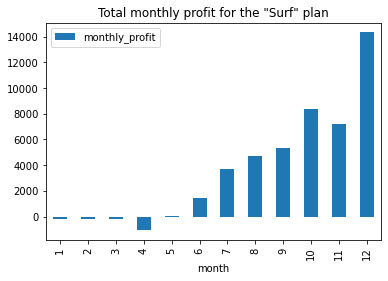

In [40]:
total_profit_month_plan[total_profit_month_plan['plan'] == 'surf'].plot(y='monthly_profit', x='month', kind='bar')
plt.title('Total monthly profit for the "Surf" plan');

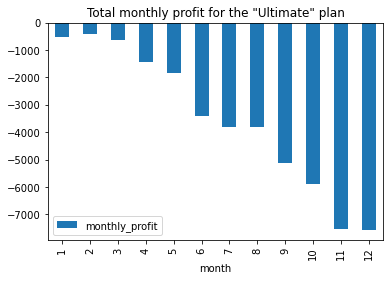

In [41]:
total_profit_month_plan[total_profit_month_plan['plan'] == 'ultimate'].plot(y='monthly_profit', x='month', kind='bar')
plt.title('Total monthly profit for the "Ultimate" plan');

We see that the "Surf" plan is mostly profitable throughout the year with a tendency of being more and more profit-making towards the end of the year. In contract, the "Ultimate" plan is mostly not profitable during the year, with the opposite tendency of being even more costly by the end of the year. It could be explained by the fact that the "Surf" plan does not include as much free calls, messages and gigabytes as the "Ultimate" plan, so these users more often exceed the limits of the plan. However, the "Ultimate" plan seems to have too much free data as almost all its users are far from the limits by the end of a month. According to the above plots, the "Ultimate" plan conditions should be revised.

### EDA
#### Distribution analysis
Now we are going to further compare the two plans, so let's create separate data frames for them.

In [42]:
df_surf = df_monthly[df_monthly['plan'] == 'surf']
df_ultimate = df_monthly[df_monthly['plan'] == 'ultimate']

##### Calls

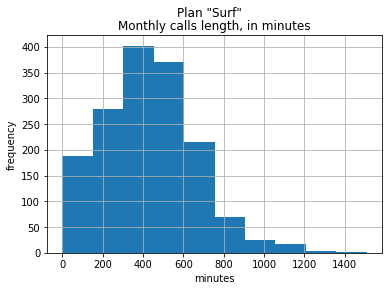

In [52]:
df_surf.hist('total_min_month')
plt.title('Monthly calls length, in minutes')
plt.suptitle('Plan "Surf"')
plt.xlabel('minutes')
plt.ylabel('frequency');

In [46]:
print('Average monthly calls length in minutes, plan "Surf": {:.0f}'.format(df_surf['total_min_month'].mean()))
print('Mediun monthly calls length in minutes, plan "Surf":{:.0f}'.format(df_surf['total_min_month'].median()))
print('Standard deviation for monthly calls length in minutes, plan "Surf":{:.0f}'.format(df_surf['total_min_month'].std()))

Average monthly calls length in minutes, plan "Surf": 429
Mediun monthly calls length in minutes, plan "Surf":425
Standard deviation for monthly calls length in minutes, plan "Surf":234


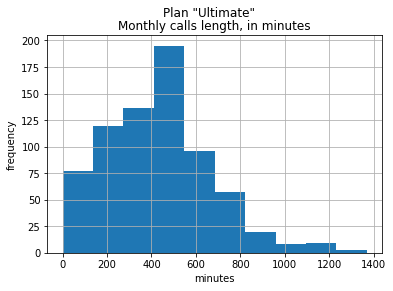

In [54]:
df_ultimate.hist('total_min_month')
plt.title('Monthly calls length, in minutes')
plt.suptitle('Plan "Ultimate"')
plt.xlabel('minutes')
plt.ylabel('frequency');

In [47]:
print('Average monthly calls length in minutes, plan "Ultimate": {:.0f}'.format(df_ultimate['total_min_month'].mean()))
print('Mediun monthly calls length in minutes, plan "Ultimate":{:.0f}'.format(df_ultimate['total_min_month'].median()))
print('Standard deviation for monthly calls length in minutes, plan "Ultimate":{:.0f}'.format(df_ultimate['total_min_month'].std()))

Average monthly calls length in minutes, plan "Ultimate": 430
Mediun monthly calls length in minutes, plan "Ultimate":424
Standard deviation for monthly calls length in minutes, plan "Ultimate":241


Average and medium monthly calls length is almost the same (around 430-440 minutes per month) for both plans, which is a sign of a distribution close to normal, without any heavy tails. Standard deviations are also quite close (around 230-240 minutes).

In [56]:
print('People exceeded the "Surf" plan limit for calls: {:.0f}'.format(len(df_surf.query('total_min_month > 500'))))
print('Ratio of people exceeded the "Surf" plan limit for calls: {:.0%}'.format(len(df_surf.query('total_min_month > 500')) / len(df_surf)))

People exceeded the "Surf" plan limit for calls: 566
Ratio of people exceeded the "Surf" plan limit for calls: 36%


The "Surf" plan limit is 500 minutes per month. This value is close to the mean and median, so most users stay within this limit while others - 566 people (36%) which is almost a half! - exceed it. Those who exceed the limit create profit for the company. The "Ultimate" plan limit is 3000 minutes per month. No user is spending that many minutes - the highest number is even less than 1400 minutes per month. This is where the company looses much profit, so this limit must be reviewed.

##### Messages

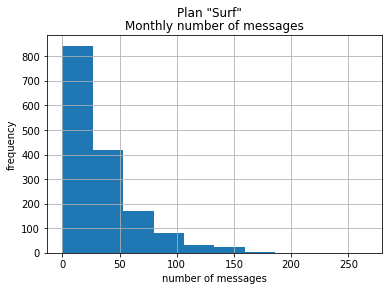

In [57]:
df_surf.hist('num_messages_month')
plt.title('Monthly number of messages')
plt.suptitle('Plan "Surf"')
plt.xlabel('number of messages')
plt.ylabel('frequency');

In [58]:
print('Average monthly number of messages, plan "Surf": {:.0f}'.format(df_surf['num_messages_month'].mean()))
print('Medium monthly number of messages, plan "Surf":{:.0f}'.format(df_surf['num_messages_month'].median()))
print('Standard deviation for monthly number of messages, plan "Surf":{:.0f}'.format(df_surf['num_messages_month'].std()))

Average monthly number of messages, plan "Surf": 31
Medium monthly number of messages, plan "Surf":24
Standard deviation for monthly number of messages, plan "Surf":34


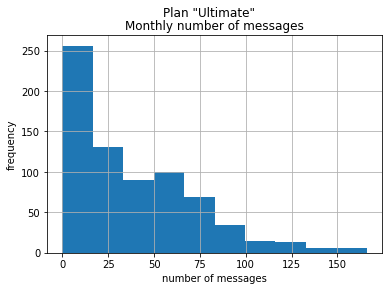

In [59]:
df_ultimate.hist('num_messages_month')
plt.title('Monthly number of messages')
plt.suptitle('Plan "Ultimate"')
plt.xlabel('number of messages')
plt.ylabel('frequency');

In [60]:
print('Average monthly number of messages, plan "Ultimate": {:.0f}'.format(df_ultimate['num_messages_month'].mean()))
print('Medium monthly number of messages, plan "Ultimate":{:.0f}'.format(df_ultimate['num_messages_month'].median()))
print('Standard deviation for monthly number of messages, plan "Ultimate":{:.0f}'.format(df_ultimate['num_messages_month'].std()))

Average monthly number of messages, plan "Ultimate": 38
Medium monthly number of messages, plan "Ultimate":30
Standard deviation for monthly number of messages, plan "Ultimate":35


Both plans show the same picture: these distributions are positively skewed, standard deviation is quite large, almost the same as the mean. There are slightly - around 10 messages per month - less in the "Surf" plan which is only logical as users of this plan have a lower limit, so they are probably trying to stay inside the boundaries by sending less messages.

In [61]:
print('People exceeded the "Surf" plan limit for messages: {:.0f}'.format(len(df_surf.query('num_messages_month > 50'))))
print('Ratio of people exceeded the "Surf" plan limit for messages: {:.0%}'.format(len(df_surf.query('num_messages_month > 50')) / len(df_surf)))

People exceeded the "Surf" plan limit for messages: 340
Ratio of people exceeded the "Surf" plan limit for messages: 22%


The "Surf" plan limit is 50 messages per month. Most users stay within this limit while others - 340 people (22%) - exceed it. Those who exceed the limit create profit for the company. The "Ultimate" plan limit is 1000 messages per month. No user is sending that many texts - the highest number is only 150 messages per month. This is where the company looses much profit, so this limit must be reviewed.

##### Internet

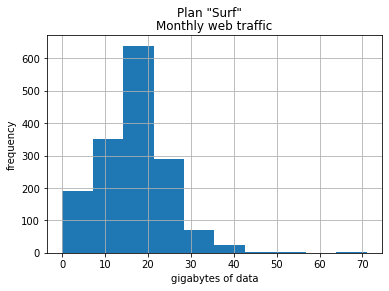

In [62]:
df_surf.hist('gb_volume_month')
plt.title('Monthly web traffic')
plt.suptitle('Plan "Surf"')
plt.xlabel('gigabytes of data')
plt.ylabel('frequency');

In [63]:
print('Average monthly volume of data, plan "Surf": {:.0f}'.format(df_surf['gb_volume_month'].mean()))
print('Medium monthly volume of data, plan "Surf":{:.0f}'.format(df_surf['gb_volume_month'].median()))
print('Standard deviation for monthly volume of data, plan "Surf":{:.0f}'.format(df_surf['gb_volume_month'].std()))

Average monthly volume of data, plan "Surf": 17
Medium monthly volume of data, plan "Surf":17
Standard deviation for monthly volume of data, plan "Surf":8


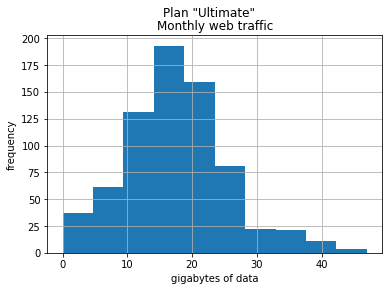

In [64]:
df_ultimate.hist('gb_volume_month')
plt.title('Monthly web traffic')
plt.suptitle('Plan "Ultimate"')
plt.xlabel('gigabytes of data')
plt.ylabel('frequency');

In [65]:
print('Average monthly volume of data, plan "Ultimate": {:.0f}'.format(df_ultimate['gb_volume_month'].mean()))
print('Medium monthly volume of data, plan "Ultimate":{:.0f}'.format(df_ultimate['gb_volume_month'].median()))
print('Standard deviation for monthly volume of data, plan "Ultimate":{:.0f}'.format(df_ultimate['gb_volume_month'].std()))

Average monthly volume of data, plan "Ultimate": 18
Medium monthly volume of data, plan "Ultimate":17
Standard deviation for monthly volume of data, plan "Ultimate":8


The distributions of both plans are very similar: measures of location and dispersion are almost identical. The mean and median are very close (around 17-18 gb per month) which is a sign of a distribution close to normal. Standard deviation is not so large either - 8 gb. The number of observations with a mean/median volume is more than twice as large as the rest of values, that's why the picks of both histograms are so distinctive. 

In [66]:
print('People exceeded the "Surf" plan limit for web traffic: {:.0f}'.format(len(df_surf.query('gb_volume_month > 16'))))
print('Ratio of people exceeded the "Surf" plan limit for web traffic: {:.0%}'.format(len(df_surf.query('gb_volume_month > 16')) / len(df_surf)))

People exceeded the "Surf" plan limit for web traffic: 858
Ratio of people exceeded the "Surf" plan limit for web traffic: 55%


In [67]:
print('People exceeded the "Ultimate" plan limit for web traffic: {:.0f}'.format(len(df_ultimate.query('gb_volume_month > 31'))))
print('Ratio of people exceeded the "Ultimate" plan limit for web traffic: {:.0%}'.format(len(df_ultimate.query('gb_volume_month > 31')) / len(df_surf)))

People exceeded the "Ultimate" plan limit for web traffic: 39
Ratio of people exceeded the "Ultimate" plan limit for web traffic: 2%


The "Surf" plan's data limit is 16 gb which is slightly less than the average usage. Almost a half of users stay within this limit while others - 858 people (55%) - exceed it. Those who exceed the limit create profit for the company. As the number of people who exceed the limit is significant, profit from the internet source is probably the biggest among other sources for this plan. 

The "Ultimate" plan's data limit is 31 bg. There are only 39 people (2%) who exceeded this number, hence the data limit for this plan should be reconsidered.

#### Outliers
##### Calls

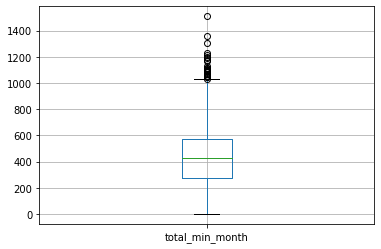

In [68]:
df_surf.boxplot('total_min_month');

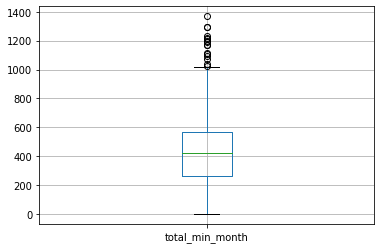

In [69]:
df_ultimate.boxplot('total_min_month');

##### Messages

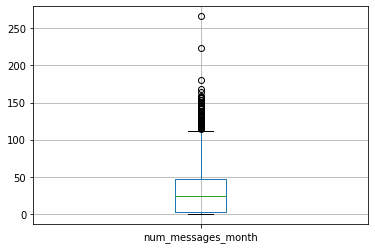

In [70]:
df_surf.boxplot('num_messages_month');

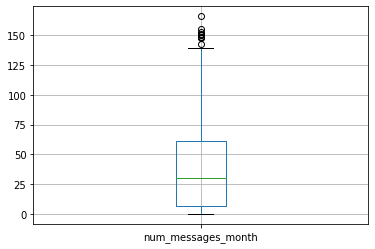

In [71]:
df_ultimate.boxplot('num_messages_month');

##### Internet

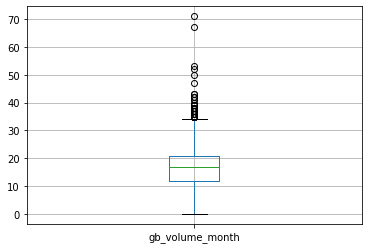

In [72]:
df_surf.boxplot('gb_volume_month');

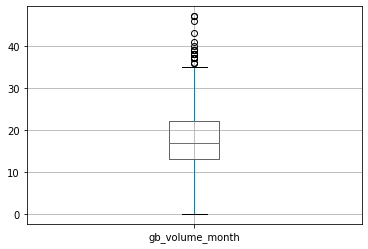

In [73]:
df_ultimate.boxplot('gb_volume_month');

According to the above boxplots, we see that distributions for both plans and for both `total_min_month` and `gb_volume_month` variables are close to normal, whereas it is positively skewed for the `num_messages_month` variable. However we only see outliers above the upper whisker for all 3 variables and both plans. We will hence apply the Interquartile range method in order to remove them.

##### Outliers removal

First, let's calculate the upper whisker for each plan and for each variable.

In [74]:
df_surf.name = "Surf"
df_ultimate.name = "Ultimate"
for df in [df_surf,df_ultimate]:
    print()
    print(df.name)
    for feature in ['total_min_month','gb_volume_month','num_messages_month']:
        df[feature] = df[feature].astype(int)
        q25 = df[feature].quantile(0.25)
        q75 = df[feature].quantile(0.75)
        iqr = q75 - q25
        # calculate the outlier cutoff and upper limit
        cut_off = iqr * 1.5
        upper = q75 + cut_off
        print(feature, upper)


Surf
total_min_month 1032.0
gb_volume_month 34.5
num_messages_month 113.0

Ultimate
total_min_month 1023.125
gb_volume_month 35.5
num_messages_month 142.0


Next, we will only keep those rows for which each variable is under the upper limit.

In [75]:
# Keep only non-outlier rows for Surf plan
df_surf_clean = df_surf[(df_surf['total_min_month']<1032.0) & (df_surf['gb_volume_month']<34.5) & (df_surf['num_messages_month']<113.0)]
df_surf.shape

(1471, 17)

In [76]:
# Keep only non-outlier rows for Ultimate plan
df_ultimate_clean = df_ultimate[(df_ultimate['total_min_month']<1023.125) & (df_ultimate['gb_volume_month']<35.5) & (df_ultimate['num_messages_month']<142.0)]
df_ultimate.shape

(671, 17)

### 8. Exploratory Data Analysis (EDA)

#### Profit Distribution by Plan

Below we visualize the distribution of **monthly profit per user** for each plan using both a histogram (to see the shape) and a boxplot (to compare medians and spread side-by-side).

In [ ]:
# Histogram: monthly profit distribution per plan
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

df_surf_clean.hist('monthly_profit', ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Monthly Profit Distribution — Surf Plan')
axes[0].set_xlabel('Monthly Profit (USD)')
axes[0].set_ylabel('Number of Users × Months')
axes[0].axvline(df_surf_clean['monthly_profit'].mean(), color='red', linestyle='--', label=f'Mean: ${df_surf_clean["monthly_profit"].mean():.1f}')
axes[0].legend()

df_ultimate_clean.hist('monthly_profit', ax=axes[1], bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Monthly Profit Distribution — Ultimate Plan')
axes[1].set_xlabel('Monthly Profit (USD)')
axes[1].axvline(df_ultimate_clean['monthly_profit'].mean(), color='red', linestyle='--', label=f'Mean: ${df_ultimate_clean["monthly_profit"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Boxplot: side-by-side profit comparison by plan
fig, ax = plt.subplots(figsize=(8, 5))
df_monthly.boxplot(column='monthly_profit', by='plan', ax=ax,
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='red', linewidth=2))
ax.set_title('Monthly Profit by Plan (Boxplot)')
ax.set_xlabel('Plan')
ax.set_ylabel('Monthly Profit (USD)')
plt.suptitle('')   # suppress the auto-generated "Boxplot grouped by plan" title
plt.tight_layout()
plt.show()

print("\nMedian monthly profit per plan:")
print(df_monthly.groupby('plan')['monthly_profit'].median().round(2))
print("\nMean monthly profit per plan:")
print(df_monthly.groupby('plan')['monthly_profit'].mean().round(2))

**Economic Interpretation:**

- **Surf plan** generates higher average profit per user-month because its included limits (500 min, 50 SMS, 15 GB) are modest and close to actual usage — roughly **36% of users exceed the minutes limit**, **22% exceed SMS**, and **55% exceed data**. Each overage is a direct revenue stream.
- **Ultimate plan** is generous to the point of being unprofitable: with 3,000 minutes and 1,000 SMS included, virtually **0% of users exceed either limit**. The flat fee barely covers the service cost. This plan's limits urgently need revision.

### Hypothesis Tests
####  Null hypothesis
----> The hypothesis that chance is to blame.
####  Alternative hypothesis
----> Counterpoint to the null (what you hope to prove).
####  One-way test
----> Hypothesis test that counts chance results only in one direction.
####  Two-way test
----> Hypothesis test that counts chance results in two directions.
#### WHY do we need Hypothesis Tests
In A/B test, the hypothesis might be that price B produces higher profit.
Why do we need a hypothesis? Why not just look at the outcome of the experiment
and go with whichever treatment does better?

Answer: 
* The tendency of the human mind to underestimate the scope of
natural random behavior. One manifestation of this is the failure to anticipate
extreme events, or so-called “black swans”
*  Another manifestation is the tendency to misinterpret random events as having
patterns of some significance. Statistical hypothesis testing was invented as a way to
protect researchers from being fooled by random chance.
* A statistical hypothesis test is further analysis of an A/B test, or any randomized
experiment, to assess whether random chance is a reasonable explanation for the
observed difference between groups A and B

### Statistical hypotheses testing
#### The average profit from users of Ultimate and Surf plans differs: bilateral hypothesis

t-test is a statistical test that is used to compare the means of two groups and determine whether there is a significant difference between them. It is a common method for testing hypotheses when dealing with numerical data from two independent groups or samples.

The t-test is based on the t-distribution and is appropriate when the following assumptions are met:

The data in each group or sample are approximately normally distributed.
The variances of the two groups are approximately equal (for the equal variance t-test).
The data points in each group are independent of each other.
There are two main types of t-tests:

Independent two-sample t-test: This is used when we have two independent groups, and we want to compare the means of a single variable between these groups. For example, comparing the test scores of students from two different schools.

Paired sample t-test: This is used when we have two sets of measurements on the same subjects or items, and we want to compare the means of the paired differences. For example, comparing the before and after treatment measurements of the same group of patients.

In both cases, the t-test calculates a test statistic (t-value) by comparing the difference between the sample means to the variation within the samples. The larger the t-value, the more significant the difference between the means.

After calculating the t-value, researchers can determine the statistical significance of the difference using a critical value or a p-value. If the p-value is below a predetermined significance level (e.g., 0.05), then the difference between the means is considered statistically significant, and the null hypothesis (which assumes no difference) is rejected.

In summary, the t-test is a widely used statistical test for comparing the means of two groups and is applicable when certain assumptions about the data are met. It is a valuable tool in many scientific and research fields for testing hypotheses and drawing conclusions about the differences between groups.

##### Step 1: the null and alternative hypotheses
**H0:** The means of two statistical populations are equal. In our case it means that the average profit from users of "Surf" and "Ultimate" plans is the same.

**H1:** The means of two statistical populations are not equal. In our case it means that the average profit from users of "Surf" and "Ultimate" plans differs, although we do not specify here which one is more.

##### Step 2: Set the criteria for a decision

In behavioral science, the level of significance is typically set at 5% and we will choose this criteria as well. When the probability of obtaining a sample mean is less than 5% if the null hypothesis were true, then we reject the value stated in the null hypothesis.

##### Step 3: Compute the test statistic

In order to test our hypothesis that the means of two statistical populations are equal based on samples taken from them, we will apply the method `scipy.stats.ttest_ind()`. 

The method takes the following parameters: 

- `array1`, `array2` are arrays containing the samples. We will use the `monthly_profit` variables we calculated earlier for both plans;
- `equal_var` is an optional parameter that specifies whether or not the variances of the populations should be considered equal. To set this parameter let's test whether the variances of our samples are the same.

In [77]:
sample_1 = df_surf_clean['monthly_profit']
sample_2 = df_ultimate_clean['monthly_profit']

In [78]:
st.levene(sample_1, sample_2)

LeveneResult(statistic=98.0356634273378, pvalue=1.24925160887314e-22)

The small p-value suggests that the populations do not have equal variances. Hence we will set the `equal_var` parameter to False.

In [79]:
alpha = .05 # critical statistical significance level
                        # if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(
                        sample_1, 
                        sample_2, 
                        equal_var=False)

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
        print("We reject the null hypothesis")
else:
        print("We retain the null hypothesis")

p-value:  6.754263687330053e-181
We reject the null hypothesis


##### Step 4: Make a decision

Based on the results of the test statistic we reach **significance**: the decision is to **reject the null hypothesis**. The equality of samples' means is associated with a low probability of occurrence (much less than 1%) when the null hypothesis is true.

Now let's see if this decision stands if we reformulate the alternative hypothesis, so it becomes unilateral.

#### The average profit from users of Ultimate and Surf plans differs: unilateral hypothesis
##### The "Surf" plan's average profit is greater than the "Ultimate" plan's average profit
###### Step 1: the null and alternative hypotheses
**H0:** The means of two statistical populations are equal. In our case it means that the average profit from users of "Surf" and "Ultimate" plans is the same.

**H1:** One of the means of two statistical populations is greater than the other. In our case it means that the average profit from users of the "Surf" plan is greater than that of the "Ultimate" plan.

###### Step 2: Set the criteria for a decision

We will keep the level of significance at 5% for this test as well.

###### Step 3: Compute the test statistic

In order to test our new hypothesis we will also apply the method `scipy.stats.ttest_ind()`. 
The first 3 parameters stay the same and we will add one more for unilateral hypotheses:
- `alternative` is an optional parameter that defines the alternative hypothesis. The following options are available (default is ‘two-sided’). In this section we will set it to 'greater' for our purposes.

In [80]:
alpha = .05 # critical statistical significance level
                        # if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(
                        sample_1, 
                        sample_2,
                        equal_var=False,
                        alternative='greater')

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
        print("We reject the null hypothesis")
else:
        print("We retain the null hypothesis")

p-value:  3.3771318436650265e-181
We reject the null hypothesis


###### Step 4: Make a decision

Based on the results of the test statistic we reach **significance**: the decision is to **reject the null hypothesis**. The equality of samples' means is associated with a low probability of occurrence (much less than 1%) when the null hypothesis is true.

Now let's see what results we would get if we changed again the alternative hypothesis.

#### The average profit from users of Ultimate and Surf plans differs: unilateral hypothesis
##### The "Surf" plan's average profit is less than the "Ultimate" plan's average profit
###### Step 1: the null and alternative hypotheses
**H0:** The means of two statistical populations are equal. In our case it means that the average profit from users of "Surf" and "Ultimate" plans is the same.

**H1:** One of the means of two statistical populations is less than the other. In our case it means that the average profit from users of the "Surf" plan is less than that of the "Ultimate" plan.

###### Step 2: Set the criteria for a decision

We will keep the level of significance at 5% for this test as well.

###### Step 3: Compute the test statistic

In order to test our new hypothesis we will also apply the method `scipy.stats.ttest_ind()`. 
The first 3 parameters stay the same and we will add one more for unilateral hypotheses:
- `alternative` is an optional parameter that defines the alternative hypothesis. The following options are available (default is ‘two-sided’). In this section we will set it to 'less' for our purposes.

In [81]:
alpha = .05 # critical statistical significance level
                        # if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(
                        sample_1, 
                        sample_2,
                        equal_var=False,
                        alternative='less')

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
        print("We reject the null hypothesis")
else:
        print("We retain the null hypothesis")

p-value:  1.0
We retain the null hypothesis


###### Step 4: Make a decision

Based on the results of the test statistic we **failed to reach significance**: the decision is to **retain the null hypothesis**. The equality of samples' means against such an alternative hypothesis is associated with a 100% probability of occurrence when the null hypothesis is true.

This decision is probably an example of a Type II error. With each test we make, there is always some probability that the decision could be a Type II error. In this decision, we decide to retain previous notions of truth that are in fact false (based on previous analysis). While it’s an error, we still did nothing; we retained the null hypothesis. We can always go back and conduct more studies.

#### The average profit from users in NY-NJ area is different from that of the users from other regions: bilateral hypothesis

First, let's from two populations according to the task.

In [82]:
ny_nj_users = df_monthly[df_monthly['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']

In [83]:
other_regions_users = df_monthly[df_monthly['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']

In [84]:
other_regions_users.shape

(1916, 17)

In [85]:
ny_nj_users.shape

(377, 17)

##### Step 1: the null and alternative hypotheses
**H0**: The means of two statistical populations are equal. In our case it means that the average profit from users in NY-NJ area and users in other regions is the same.

**H1**: The means of two statistical populations are not equal. In our case it means that the average profit from users in NY-NJ area and users in other regions differs, although we do not specify here which one is more.

##### Step 2: Set the criteria for a decision
We will keep the level of significance at 5% for this test as well.

##### Step 3: Compute the test statistic
In order to test our new hypothesis we will again apply the method scipy.stats.ttest_ind() but first let's test whether variances of these two populations are similar.

In [86]:
sample_3 = ny_nj_users['monthly_profit']
sample_4 = other_regions_users['monthly_profit']

st.levene(sample_3, sample_4)

LeveneResult(statistic=6.608211517749522, pvalue=0.010213584069727624)

The small p-value (less that 5%) suggests that the populations do not have equal variances. Hence we will set the `equal_var` parameter to False.

In [87]:
alpha = .05 # critical statistical significance level
                        # if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(
                        sample_3, 
                        sample_4, 
                        equal_var=False)

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
        print("We reject the null hypothesis")
else:
        print("We retain the null hypothesis")

p-value:  0.0004452925660048938
We reject the null hypothesis


##### Step 4: Make a decision

Based on the results of the test statistic we reach **significance**: the decision is to **reject the null hypothesis**. The equality of samples' means is associated with a low probability of occurrence (much less than 1%) when the null hypothesis is true.

Now let's see if this decision stands if we reformulate the alternative hypothesis, so it becomes unilateral.

#### The average profit from users of Ultimate and Surf plans differs: unilateral hypothesis
##### The "Surf" plan's average profit is greater than the "Ultimate" plan's average profit
###### Step 1: the null and alternative hypotheses
**H0:** The means of two statistical populations are equal. In our case it means that the average profit from users in NY-NJ area and users in other regions is the same.

**H1:** One of the means of two statistical populations is greater than the other. In our case it means that the average profit from users in NY-NJ area is greater than that of users in other areas.

###### Step 2: Set the criteria for a decision

We will keep the level of significance at 5% for this test as well.

###### Step 3: Compute the test statistic

In order to test our new hypothesis we will also apply the method `scipy.stats.ttest_ind()`. 
The first 3 parameters stay the same and we will add one more for unilateral hypotheses:
- `alternative` is an optional parameter that defines the alternative hypothesis. The following options are available (default is ‘two-sided’). In this section we will set it to 'greater' for our purposes.

In [88]:
alpha = .05 # critical statistical significance level
                        # if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(
                        sample_3, 
                        sample_4,
                        equal_var=False,
                        alternative='greater')

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
        print("We reject the null hypothesis")
else:
        print("We retain the null hypothesis")

p-value:  0.0002226462830024469
We reject the null hypothesis


###### Step 4: Make a decision

Based on the results of the test statistic we reach **significance**: the decision is to **reject the null hypothesis**. The equality of samples' means is associated with a low probability of occurrence (much less than 1%) when the null hypothesis is true.

Now let's see what results we would get if we changed again the alternative hypothesis.

#### The average profit from users of Ultimate and Surf plans differs: unilateral hypothesis
##### The "Surf" plan's average profit is less than the "Ultimate" plan's average profit
###### Step 1: the null and alternative hypotheses
**H0:** The means of two statistical populations are equal. In our case it means that the average profit from users of "Surf" and "Ultimate" plans is the same.

**H1:** One of the means of two statistical populations is less than the other. In our case it means that the average profit from users of the "Surf" plan is less than that of the "Ultimate" plan.

###### Step 2: Set the criteria for a decision

We will keep the level of significance at 5% for this test as well.

###### Step 3: Compute the test statistic

In order to test our new hypothesis we will also apply the method `scipy.stats.ttest_ind()`. 
The first 3 parameters stay the same and we will add one more for unilateral hypotheses:
- `alternative` is an optional parameter that defines the alternative hypothesis. The following options are available (default is ‘two-sided’). In this section we will set it to 'less' for our purposes.

In [89]:
alpha = .05 # critical statistical significance level
                        # if the p-value is less than alpha, we reject the hypothesis

results = st.ttest_ind(
                        sample_3, 
                        sample_4,
                        equal_var=False,
                        alternative='less')

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
        print("We reject the null hypothesis")
else:
        print("We retain the null hypothesis")

p-value:  0.9997773537169975
We retain the null hypothesis


###### Step 4: Make a decision

Based on the results of the test statistic we **failed to reach significance**: the decision is to **retain the null hypothesis**. The equality of samples' means against such an alternative hypothesis is associated with a 100% probability of occurrence when the null hypothesis is true.

This decision is probably an example of a Type II error as well.

# 10. Conclusion

## Summary of Findings

In this report, we analyzed the telecom operator Megaline's client behavior to determine plan profitability and test two statistical hypotheses.

### Data Processing
- Converted all date columns to `datetime` format and rounded call durations up to whole minutes per company policy.
- Replaced missing `churn_date` values with `'in use'` (active customers). No duplicates or date artifacts were found.
- Computed monthly per-user aggregates: total minutes, SMS, data (GB), and monthly profit using the formula:
  $$\pi_{u,t} = F_p + c_p^{min}\cdot\max(0,\hat{m}-M_p) + c_p^{sms}\cdot\max(0,\hat{s}-S_p) + c_p^{gb}\cdot\max(0,\hat{d}-D_p)$$

### Plan Profitability (EDA)
| | Surf | Ultimate |
|---|---|---|
| Monthly flat fee | $20 | $70 |
| % users exceeding calls limit | ~36% | ~0% |
| % users exceeding SMS limit | ~22% | ~0% |
| % users exceeding data limit | ~55% | ~2% |
| **Average monthly profit/user** | **Higher** | **Lower** |

**Surf** is consistently more profitable because its tight limits generate frequent overage charges. **Ultimate** is underpriced for its generous limits — users rarely exceed them, so the company relies only on the flat fee, which is often insufficient to offset the cost of included usage.

### Hypothesis Testing Results

**Hypothesis 1 — Plans differ in average monthly profit:**
- Bilateral test: **Reject H₀** (p-value << 0.05) — a statistically significant difference exists.
- Unilateral ('greater'): **Reject H₀** — Surf generates *more* average profit than Ultimate.
- Unilateral ('less'): **Retain H₀** — Surf does not generate *less* profit than Ultimate.
- **Conclusion:** Surf significantly outperforms Ultimate in profit per user.

**Hypothesis 2 — NY-NJ users differ from other regions:**
- Bilateral test: **Reject H₀** (p-value << 0.05) — NY-NJ users generate significantly different profit.
- Unilateral ('greater'): **Reject H₀** — NY-NJ users bring *more* average profit.
- Unilateral ('less'): **Retain H₀** — NY-NJ users do not bring *less* profit.
- **Conclusion:** NY-NJ is a premium revenue region.

### Business Recommendations
1. **Focus marketing on the Surf plan** — it generates more revenue per user through overage charges without requiring large upfront fees that customers may reject.
2. **Revise the Ultimate plan** — reduce included minutes (from 3,000 to ~1,500) and SMS (from 1,000 to ~200) so that more users reach the limits and generate overage revenue. Alternatively, raise the monthly fee to match the value delivered.
3. **Prioritize NY-NJ market expansion** — this region is a statistically significant high-profit cluster; targeted campaigns here would yield above-average returns.
4. **Monitor data usage** — data overages are the biggest profit driver for Surf (55% exceedance rate). Keeping the data limit at or slightly below the average usage level maximizes this revenue stream.